In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import least_squares
from scipy.signal import butter, filtfilt
from scipy.signal import savgol_filter

In [2]:
# Funciones auxiliares
def extraccion_datos(var, pos):
    """
    Extrae datos de un archivo de registro.
    
    Args:
        var: Variable a extraer
        pos: Posición de la variable en la línea
    
    Returns:
        Tupla con los datos extraídos y sus tiempos correspondientes
    """
    home_dir = os.path.expanduser("~")
    ruta_datos = os.path.join(home_dir, "paparazzi", "var", "logs", "25_05_28__16_27_03.data")
    
    dato = []
    tiempo = []
    with open(ruta_datos, "r", encoding="utf-8") as file:
        for line in file:
            if var in line:
                campos = line.strip().split()
                if campos[2] == var:
                    dato.append(float(campos[pos]))
                    tiempo.append(float(campos[0]))
    return np.array(dato), np.array(tiempo)


def filtrado_tiempo_comun(t_comun, dt_min=0.1, dt_max=1):
    """
    Filtra los tiempos para obtener intervalos regulares.
    
    Args:
        t_comun: Array de tiempos a filtrar
        dt_min: Intervalo mínimo entre muestras
        dt_max: Intervalo máximo entre muestras
    
    Returns:
        Tiempos filtrados e índices correspondientes
    """
    dt = np.gradient(t_comun)
    mask = (dt >= dt_min) & (dt <= dt_max)
    mask[0] = True
    indices = np.where(mask)[0]
    t_filtrado = t_comun[indices]
    
    return t_filtrado, indices


def interp_to_common(t_original, data_original, t_comun):
    """
    Interpola datos a una base de tiempo común.
    
    Args:
        t_original: Tiempos originales
        data_original: Datos originales
        t_comun: Base de tiempo común para interpolación
    
    Returns:
        Datos interpolados
    """
    interp_func = interp1d(t_original, data_original, kind='linear', bounds_error=False, fill_value="extrapolate")
    return interp_func(t_comun)

def filtro_butterworth(data, cutoff_freq, fs, order=4):
    """
    Aplica un filtro Butterworth pasa-bajos.
    
    Args:
        data: Datos a filtrar
        cutoff_freq: Frecuencia de corte (Hz)
        fs: Frecuencia de muestreo (Hz)
        order: Orden del filtro
        
    Returns:
        Datos filtrados
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def calcular_trayectoria(t, u, v, orientacion):
    """
    Calcula la trayectoria (posiciones x, y) a partir de las velocidades y orientación.
    
    Args:
        t: Array de tiempos
        u: Array de velocidades en dirección x (en el sistema del vehículo)
        v: Array de velocidades en dirección y (en el sistema del vehículo)
        orientacion: Array de orientaciones (ángulos en radianes)
        
    Returns:
        Tupla con (posiciones_x, posiciones_y)
    """
    # Inicializar arrays de posición
    n = len(t)
    x = np.zeros(n)
    y = np.zeros(n)
    
    # Calcular posiciones mediante integración de velocidades
    for i in range(1, n):
        dt = t[i] - t[i-1]
        
        # Velocidades en el sistema global
        vx_global = u[i-1] * np.cos(orientacion[i-1]) - v[i-1] * np.sin(orientacion[i-1])
        vy_global = u[i-1] * np.sin(orientacion[i-1]) + v[i-1] * np.cos(orientacion[i-1])
        
        # Integración simple (método de Euler)
        x[i] = x[i-1] + vx_global * dt
        y[i] = y[i-1] + vy_global * dt
    
    return x, y

In [3]:
##### PARA SELECCIONAR EL TRAMO QUE SE VA A ESTUDIAR #######
def tramo_minima_dependencia(indices, v_lineal, omega_abs, tipo='traslacion', min_length=10):
    """
    Selecciona el tramo continuo que minimiza la dependencia cruzada.
    
    Args:
        indices: Array de índices a analizar
        v_lineal: Array de velocidades lineales
        omega_abs: Array de velocidades angulares absolutas
        tipo: 'traslacion' o 'rotacion', indica el tipo de tramo a seleccionar
        min_length: Longitud mínima que debe tener un segmento para ser considerado
        
    Returns:
        Array con el segmento que minimiza la dependencia cruzada
    """
    if len(indices) == 0:
        return indices
    
    # Detecta rupturas de continuidad
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    
    # Filtra segmentos de al menos longitud mínima
    segmentos_validos = [seg for seg in segmentos if len(seg) >= min_length]
    
    if not segmentos_validos:
        return np.array([], dtype=int)
    
    # Calcula la métrica de dependencia para cada segmento
    if tipo == 'traslacion':
        # Para traslación, queremos minimizar la velocidad angular
        metricas = [np.mean(omega_abs[seg]) for seg in segmentos_validos]
        # Normalizar por la velocidad lineal para favorecer segmentos con alta velocidad lineal
        metricas_normalizadas = [metricas[i] / (np.mean(v_lineal[seg]) + 1e-6) 
                               for i, seg in enumerate(segmentos_validos)]
        # Seleccionar el segmento con la menor métrica normalizada
        mejor_segmento = segmentos_validos[np.argmin(metricas_normalizadas)]
        
    elif tipo == 'rotacion':
        # Para rotación, queremos minimizar la velocidad lineal
        metricas = [np.mean(v_lineal[seg]) for seg in segmentos_validos]
        # Normalizar por la velocidad angular para favorecer segmentos con alta velocidad angular
        metricas_normalizadas = [metricas[i] / (np.mean(omega_abs[seg]) + 1e-6) 
                               for i, seg in enumerate(segmentos_validos)]
        # Seleccionar el segmento con la menor métrica normalizada
        mejor_segmento = segmentos_validos[np.argmin(metricas_normalizadas)]
    
    return mejor_segmento
    
from scipy.stats import pearsonr

def tramo_mayor_correlacion(indices, v_lineal, omega_abs):
    """
    Selecciona el tramo donde la velocidad lineal y angular están más correlacionadas.
    
    Args:
        indices: array de índices válidos
        v_lineal: array de velocidades lineales
        omega_abs: array de velocidades angulares absolutas
        
    Returns:
        Array con los índices del mejor segmento
    """
    if len(indices) == 0:
        return indices
        
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]

    correlaciones = [
        pearsonr(v_lineal[seg], omega_abs[seg])[0] if len(seg) > 2 else 0
        for seg in segmentos_largos
    ]
    
    # Seleccionar el segmento con mayor correlación positiva
    mejor_segmento = segmentos_largos[np.argmax(correlaciones)]
    return mejor_segmento

def tramo_mas_largo(indices):
    """
    Devuelve el sub-array continuo más largo dentro de `indices`.
    
    Args:
        indices: Array de índices a analizar
        
    Returns:
        Array con el segmento continuo más largo
    """
    if len(indices) == 0:
        return indices
    # detecta rupturas de continuidad
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    # filtra segmentos de al menos longitud 2
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]
    if not segmentos_largos:
        return np.array([], dtype=int)
    # devuelve el más largo
    return max(segmentos_largos, key=len)

def tramo_mayor_velocidad(indices, velocidad):
    """
    Devuelve, dentro de los segmentos continuos en `indices`,
    aquel cuya velocidad (en el array `velocidad`) alcance el valor máximo.
    
    Args:
        indices: Array de índices a analizar
        velocidad: Array de velocidades correspondientes
        
    Returns:
        Array con el segmento que contiene la mayor velocidad
    """
    if len(indices) == 0:
        return indices
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]
    if not segmentos_largos:
        return np.array([], dtype=int)
    # selecciona el segmento con mayor pico de velocidad
    return max(segmentos_largos, key=lambda seg: np.max(velocidad[seg]))

In [4]:
def split_train_validation(indices, train_ratio=0.8):
    """
    Divide los índices en conjuntos de entrenamiento y validación.
    
    Args:
        indices: Array de índices a dividir
        train_ratio: Proporción para el conjunto de entrenamiento (0-1)
        
    Returns:
        Tupla con (índices_entrenamiento, índices_validación)
    """
    n = len(indices)
    n_train = int(train_ratio * n)
    # Aseguramos que la división sea aleatoria pero reproducible
    np.random.seed(42)
    indices_shuffled = np.random.permutation(indices)
    train_indices = indices_shuffled[:n_train]
    valid_indices = indices_shuffled[n_train:]
    return train_indices, valid_indices

In [5]:
def residuals_trans_lineal(params):
    """
    Función de residuos para el movimiento de traslación.
    Incluye solo términos lineales de fricción.
    
    Args:
        params: [mu_x_lin, mu_y_lin]
            mu_x_lin, mu_y_lin: Coeficientes de fricción lineal en x e y
    """
    #mu_x_lin = params[0]
    mu_x_lin = 2.5
    mu_y_lin = params[0]
    
    a = np.cos(orientacion_trans_smooth)
    b = np.sin(orientacion_trans_smooth)
    
    # Términos lineales
    term1_x_lin = (a**2)*mu_x_lin*u_trans_smooth
    term2_x_lin = (b**2)*mu_y_lin*u_trans_smooth
    term3_x_lin = a*b*v_trans_smooth*(mu_x_lin - mu_y_lin)
    
    # Residuos en x
    res_x = du_trans_smooth - (fa_trans * a - (term1_x_lin + term2_x_lin + term3_x_lin))
    
    # plt.figure()
    # plt.plot((fa_trans * a - (term1_x_lin + term2_x_lin + term3_x_lin)), label = "sim")
    # plt.plot(du_trans_smooth, label = "real")
    # plt.legend()
    # plt.title("comparacion real-sim - x")
    
    # Términos lineales
    term1_y_lin = (b**2)*mu_x_lin*v_trans_smooth
    term2_y_lin = (a**2)*mu_y_lin*v_trans_smooth
    term3_y_lin = a*b*u_trans_smooth*(mu_x_lin - mu_y_lin)
    
    # Residuos en y
    res_y = dv_trans_smooth - (fa_trans * b - (term1_y_lin + term2_y_lin + term3_y_lin))

    # plt.figure()
    # plt.plot((fa_trans * b - (term1_y_lin + term2_y_lin + term3_y_lin)), label = "sim")
    # plt.plot(dv_trans_smooth, label = "real")
    # plt.legend()
    # plt.title("comparacion real-sim - y")

    # Asegurar que los residuos sean finitos
    res_x = np.where(np.isfinite(res_x), res_x, 0.0)
    res_y = np.where(np.isfinite(res_y), res_y, 0.0)

    plt.figure()
    plt.plot(du_trans_smooth, label = "acc_x real")
    plt.plot(fa_trans * a - (term1_x_lin + term2_x_lin + term3_x_lin), label = "acc_x con mu_est", linestyle = "--")
    #plt.plot(du[indices_trans], label = "acc_x datos")
    plt.title("Comparación aceleraciones x")
    #plt.ylim([-1,1])
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(dv_trans_smooth, label = "acc_y real")
    plt.plot((fa_trans * b - (term1_y_lin + term2_y_lin + term3_y_lin)), label = "acc_y con mu_est", linestyle = "--")
    #plt.plot(dv[indices_trans], label = "acc_y datos")
    plt.title("Comparación aceleraciones y")
    #plt.ylim([-1,1])
    plt.legend()
    plt.show()

    return res_y

def evaluate_model_trans_lineal(params, indices):
    """
    Evalúa el modelo de traslación lineal en los índices dados.
    
    Args:
        params: Parámetros del modelo [mu_x_lin, mu_y_lin]
        indices: Índices donde evaluar el modelo
        
    Returns:
        Tupla con (du_pred, dv_pred, mse_x, mse_y)
    """
    u_eval = u_i[indices]
    v_eval = v_i[indices]
    du_eval = du[indices]
    dv_eval = dv[indices]
    fa_eval = T_L[indices] + T_R[indices]
    orientacion_eval = orientacion_i[indices]
    
    mu_x_lin = params[0]
    mu_y_lin = params[1]
    
    a = np.cos(orientacion_eval)
    b = np.sin(orientacion_eval)
    
    # Términos lineales
    term1_x_lin = (a**2)*mu_x_lin*u_eval
    term2_x_lin = (b**2)*mu_y_lin*u_eval
    term3_x_lin = a*b*v_eval*(mu_x_lin - mu_y_lin)
    
    # Aceleración predicha en x con protección contra desbordamiento
    du_pred = fa_eval * a - (term1_x_lin + term2_x_lin + term3_x_lin)
    
    # Términos lineales
    term1_y_lin = (b**2)*mu_x_lin*v_eval
    term2_y_lin = (a**2)*mu_y_lin*v_eval
    term3_y_lin = a*b*u_eval*(mu_x_lin - mu_y_lin)
    
    # Aceleración predicha en y con protección contra desbordamiento
    dv_pred = fa_eval * b - (term1_y_lin + term2_y_lin + term3_y_lin)
    
    # Asegurar que las predicciones sean finitas
    du_pred = np.where(np.isfinite(du_pred), du_pred, 0.0)
    dv_pred = np.where(np.isfinite(dv_pred), dv_pred, 0.0)
    
    # Error cuadrático medio
    mse_x = np.mean((du_eval - du_pred)**2)
    mse_y = np.mean((dv_eval - dv_pred)**2)
    
    return du_pred, dv_pred, mse_x, mse_y


In [10]:
def analizar_traslacion(rozamiento):
    """
    Función principal para ejecutar el análisis de traslación.
    """
    global u_i, v_i, du, dv, T_L, T_R, orientacion_i, v_lineal, omega_abs
    global u_trans_smooth, v_trans_smooth, du_trans_smooth, dv_trans_smooth, fa_trans, orientacion_trans_smooth
    
######################################## CARGA Y PROCESAMIENTO DE DATOS #####################################################3

    print("Cargando y procesando datos para análisis de traslación...")
    
    ### EXTRACCIÓN DE DATOS##############################################
    escala_vel = 0.0000019
    u_raw, t_u = extraccion_datos("INS", 6)
    v_raw, t_v = extraccion_datos("INS", 7)

    # Aplicamos la transformación a las velocidades
    u_escalado_original = u_raw * escala_vel  # Velocidad en x original (derecha)
    v_escalado_original = v_raw * escala_vel  # Velocidad en y original (adelante)

    # Transformamos al sistema del modelo
    u_escalado = u_escalado_original  
    v_escalado = v_escalado_original 

    # Aplicamos la misma transformación a las aceleraciones
    escala_acc = 0.0009766
    du_raw, t_du = extraccion_datos("INS", 9)
    dv_raw, t_dv = extraccion_datos("INS", 10)

    escala_pos = 0.0039063
    x_raw, t_x = extraccion_datos("INS", 3)
    y_raw, t_x = extraccion_datos("INS", 4)
    x_escalado = x_raw * escala_pos
    y_escalado = y_raw * escala_pos

    du_scaled_original = du_raw * escala_acc  
    dv_scaled_original = dv_raw * escala_acc 

    # Transformamos al sistema del modelo
    du_scaled = du_scaled_original 
    dv_scaled = dv_scaled_original  

    orientacion_raw, t_orientacion = extraccion_datos("ATTITUDE", 4)
    w_raw, t_w = extraccion_datos("BODY_RATES_ACCEL", 5)
    throttle_L, t_T_L = extraccion_datos("BOAT_CTRL", 7)
    throttle_R, t_T_R = extraccion_datos("BOAT_CTRL", 8)
    throttle_L_norm = throttle_L / 9600
    throttle_R_norm = throttle_R / 9600

    # Parámetros físicos del barco
    masa_barco = 50  # kg
    distancia_motores = 0.75/2  # m

    orientacion_corregida = orientacion_raw
    # Aplicamos el ajuste para el nuevo sistema de coordenadas
    orientacion_unwrapped = np.unwrap(orientacion_corregida)

    t_comun = t_u
    # MEJORA: Ajuste del umbral de filtrado para obtener datos más consistentes
    t_filtrado, indices_filtrado = filtrado_tiempo_comun(t_comun, dt_min=0.2, dt_max=0.6)

    # Calcular frecuencia de muestreo promedio para filtrado
    fs = 1.0 / np.mean(np.diff(t_filtrado))
    cutoff_freq = 0.5  # Hz, ajustar según las características de la señal
    orientacion_filtered = filtro_butterworth(orientacion_unwrapped, cutoff_freq, fs)

    ### INTERPOLACIÓN ###############################################
    u_interp = interp_to_common(t_u, u_escalado, t_filtrado)
    v_interp = interp_to_common(t_v, v_escalado, t_filtrado)
    du_interp = interp_to_common(t_du, du_scaled, t_filtrado)
    dv_interp = interp_to_common(t_dv, dv_scaled, t_filtrado)
    # Interpolar los datos de orientación ya desenrollados y filtrados
    orientacion_i = interp_to_common(t_orientacion, orientacion_unwrapped, t_filtrado)
    w_i = interp_to_common(t_w, w_raw, t_filtrado)
    throttle_L_i = interp_to_common(t_T_L, throttle_L_norm, t_filtrado)
    throttle_R_i = interp_to_common(t_T_R, throttle_R_norm, t_filtrado)

    ### FILTRO ######################################################
    u_i_filt = filtro_butterworth(u_interp, cutoff_freq, fs)
    v_i_filt = filtro_butterworth(v_interp, cutoff_freq, fs)
    du_i_filt = filtro_butterworth(du_interp, cutoff_freq, fs)
    dv_i_filt = filtro_butterworth(dv_interp, cutoff_freq, fs)

    
    u_body = u_i_filt * np.cos(orientacion_i) + v_i_filt * np.sin(orientacion_i)
    v_body = -u_i_filt * np.sin(orientacion_i) + v_i_filt * np.cos(orientacion_i)
    
    du_body = du_i_filt * np.cos(orientacion_i) + dv_i_filt * np.sin(orientacion_i)
    dv_body = -du_i_filt * np.sin(orientacion_i) + dv_i_filt * np.cos(orientacion_i)

    u_i = u_body
    v_i = u_body
    du = du_body
    dv = dv_body
    

    ### FUERZA MOTORES ##################################################################################
    T_L = (2.4277*(throttle_L_i)**3 + 0.4041*(throttle_L_i)**2 + 0.9662*throttle_L_i - 0.0004)*9.8/masa_barco
    T_R = (2.4277*(throttle_R_i)**3 + 0.4041*(throttle_R_i)**2 + 0.9662*throttle_R_i - 0.0004)*9.8/masa_barco
    
    dt_array = np.gradient(t_filtrado)
    r = w_i  # omega
    dr = np.gradient(w_i) / dt_array  # alpha
    du = du_scaled
    dv = dv_scaled

    # Magnitudes de movimiento
    v_lineal = np.sqrt(u_i**2 + v_i**2)
    #omega_abs = np.abs(r)
    omega_abs = r

    ### DEFINICIÓN DE UMBRALES Y SELECCIÓN DE TRAMO #########################################################################
    umbral_traslacion = 0.7  # Umbral para movimientos de traslación
    umbral_rotacion_bajo = 0.22  # Umbral más bajo para detectar inicio de rotación
    umbral_rotacion_alto = 0.3
    
    mask_activo_traslacion = (v_lineal > umbral_traslacion) & (omega_abs < umbral_rotacion_bajo) #& (omega_abs > umbral_rotacion_alto)
    indices_trans = np.where(mask_activo_traslacion)[0]

    
    # Aplicamos el criterio del tramo más largo para traslación
    if rozamiento == "x":
        #indices_trans = tramo_mayor_velocidad(indices_trans, v_lineal)
        #indices_trans = np.arange(570, 600, 1)
        indices_trans = np.arange(20, 50, 1)
    elif rozamiento == "y":
        indices_trans = np.arange(0, 70, 1)
        
    # Segmentos de datos para traslación
    u_trans = u_i[indices_trans]
    v_trans = v_i[indices_trans]
    du_trans = du[indices_trans]
    dv_trans = dv[indices_trans]
    fa_trans = T_L[indices_trans] + T_R[indices_trans]
    orientacion_trans = orientacion_i[indices_trans]
    
    u_trans_smooth = u_trans
    v_trans_smooth = v_trans
    du_trans_smooth = du_trans
    dv_trans_smooth = dv_trans
    orientacion_trans_smooth = orientacion_trans
    
    ### EN CASO DE QUE SE QUIERA COGER LA MEDIA DE LOS VALORES ################################3
    #Para simplificarlo vamos a coger la velocidad aceleración y fuerza como la media de los valores
    # print("len ui = ", len(u_i))
    # u_i[indices_trans] = np.full_like(u_i[indices_trans], np.mean(u_i[indices_trans]))
    # print("len utrans = ", len(u_trans))
    # v_i[indices_trans] = np.full_like(v_i[indices_trans], np.mean(v_i[indices_trans]))
    # du[indices_trans] = np.full_like(du[indices_trans], np.mean(du[indices_trans]))
    # dv[indices_trans] = np.full_like(dv[indices_trans], np.mean(dv[indices_trans]))

    #### UTILIZANDO LA MEDIA ############################################
    # u_trans_smooth = np.full_like(u_trans, np.mean(u_trans))
    # v_trans_smooth = np.full_like(v_trans, np.mean(v_trans))
    # du_trans_smooth = np.full_like(du_trans, np.mean(du_trans))
    # dv_trans_smooth = np.full_like(dv_trans, np.mean(dv_trans))
    # orientacion_trans_smooth = np.full_like(orientacion_trans, np.mean(orientacion_trans))
    # fa_trans = np.full_like(fa_trans, np.mean(fa_trans))

    #### UTILIZANDO LA TENDENCIA #######################################
    # t puede ser simplemente un array de 0 a len(datos)-1 si no tienes un tiempo real
    t = np.arange(len(u_trans))
    
    # Ajuste lineal (recta): grado 1
    def linear_trend_fit(data, t):
        coef = np.polyfit(t, data, deg=1)  # coef[0] = pendiente, coef[1] = ordenada
        return np.polyval(coef, t)         # reconstruye la señal ajustada
    
    # Aplicar la tendencia en vez de la media constante
    # u_trans_smooth = linear_trend_fit(u_trans, t)
    # v_trans_smooth = linear_trend_fit(v_trans, t)
    # du_trans_smooth = linear_trend_fit(du_trans, t)
    # dv_trans_smooth = linear_trend_fit(dv_trans, t)
    # orientacion_trans_smooth = linear_trend_fit(orientacion_trans, t)
    # fa_trans = linear_trend_fit(fa_trans, t)

    ### UTILIZANDO UN FILTRO ##################################################
    window_length = 5  # Debe ser impar y <= len(t)
    polyorder = 3       # Grado del polinomio
    u_trans_smooth           = savgol_filter(u_trans, window_length, polyorder)
    v_trans_smooth           = savgol_filter(v_trans, window_length, polyorder)
    du_trans_smooth          = savgol_filter(du_trans, window_length, polyorder)
    dv_trans_smooth          = savgol_filter(dv_trans, window_length, polyorder)
    orientacion_trans_smooth = savgol_filter(orientacion_trans, window_length, polyorder)
    fa_trans                 = savgol_filter(fa_trans, window_length, polyorder)

    # Optimización con valores iniciales razonables y límites 
    if rozamiento == "x":
        mu_ini_x = 3
        mu_ini_y = 0.3
    elif rozamiento == "y":
        mu_ini_x = 3
        mu_ini_y = 0.8

    mu_ini_ls = [mu_ini_y]
    bounds_trans_lineal = ([-np.inf], [np.inf])

    plt.figure()
    plt.plot(u_trans_smooth, label = "u")
    plt.plot(v_trans_smooth, label = "v")
    plt.plot(du_trans_smooth, label = "du")
    plt.plot(dv_trans_smooth, label = "dv")
    plt.plot(orientacion_trans_smooth, label = "orientacion")
    plt.legend()
    plt.show()

    print("fa_trans min/max:", np.min(fa_trans), np.max(fa_trans))
    print("orientacion_trans_smooth min/max:", np.min(orientacion_trans_smooth), np.max(orientacion_trans_smooth))
    print("u_trans_smooth min/max:", np.min(u_trans_smooth), np.max(u_trans_smooth))
    print("v_trans_smooth min/max:", np.min(v_trans_smooth), np.max(v_trans_smooth))

    
    resultado_trans_lineal = least_squares(residuals_trans_lineal, mu_ini_ls, bounds=bounds_trans_lineal)

    # Extracción de parámetros estimados
    mu_x_lin_est = 2.5
    mu_y_lin_est = resultado_trans_lineal.x

    ### COMPARACIÓN ACELERACIONES REALES CON LAS QUE SE OBTIENEN UTILIZANDO LOS ROZAMIENTOS ESTIMADOS
    a = np.cos(orientacion_trans_smooth)
    b = np.sin(orientacion_trans_smooth)

    term1_x_lin = (a**2)*mu_x_lin_est*u_trans_smooth
    term2_x_lin = (b**2)*mu_y_lin_est*u_trans_smooth
    term3_x_lin = a*b*v_trans_smooth*(mu_x_lin_est - mu_y_lin_est)

    term1_y_lin = (b**2)*mu_x_lin_est*v_trans_smooth
    term2_y_lin = (a**2)*mu_y_lin_est*v_trans_smooth
    term3_y_lin = a*b*u_trans_smooth*(mu_x_lin_est - mu_y_lin_est)

    # plt.figure()
    # plt.plot(du_trans_smooth, label = "acc_x real")
    # plt.plot(fa_trans * a - (term1_x_lin + term2_x_lin + term3_x_lin), label = "acc_x con mu_est", linestyle = "--")
    # plt.plot(du[indices_trans], label = "acc_x datos")
    # plt.title("Comparación aceleraciones x")
    # plt.ylim([-1,1])
    # plt.legend()
    # plt.show()

    # plt.figure()
    # plt.plot(dv_trans_smooth, label = "acc_y real")
    # plt.plot((fa_trans * b - (term1_y_lin + term2_y_lin + term3_y_lin)), label = "acc_y con mu_est", linestyle = "--")
    # plt.plot(dv[indices_trans], label = "acc_y datos")
    # plt.title("Comparación aceleraciones y")
    # plt.ylim([-1,1])
    # plt.legend()
    # plt.show()

    # Imprimir resultados
    print("\nResultados del modelo de traslación lineal:")
    print(f"Coeficiente de rozamiento en x (mu_x): {mu_x_lin_est:.6f}")
    print(f"Coeficiente de rozamiento en y (mu_y): {mu_y_lin_est}")

    plt.figure(figsize=(10, 4))
    plt.plot(t_filtrado, v_lineal, label='Velocidad lineal', color='blue')
    plt.plot(t_filtrado, omega_abs, label='Velocidad angular', color='green')
    plt.scatter(t_filtrado[indices_trans], v_lineal[indices_trans], 
               color='orange', label='Entrenamiento traslación', s=10)
    plt.scatter(t_filtrado[indices_trans], v_lineal[indices_trans], 
               color='cyan', label='Validación traslación', s=10, marker='x')
    plt.axhline(umbral_traslacion, color='blue', linestyle='--', linewidth=0.7, 
               label=f'Umbral traslación = {umbral_traslacion:.2f}')
    plt.axhline(umbral_rotacion_bajo, color='green', linestyle='--', linewidth=0.7, 
               label=f'Umbral rotación bajo = {umbral_rotacion_bajo:.2f}')
    plt.axhline(umbral_rotacion_alto, color='red', linestyle='--', linewidth=0.7, 
               label=f'Umbral rotación bajo = {umbral_rotacion_bajo:.2f}')    
    # Leyenda fuera del gráfico (a la derecha)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Magnitudes [m/s o rad/s]")
    plt.title("Segmentación mejorada para traslación y rotación")
    #plt.xlim([160,200])
    plt.tight_layout()
    plt.show()
    
    return mu_x_lin_est, mu_y_lin_est


Iniciando análisis de rozamiento de traslación...
Cargando y procesando datos para análisis de traslación...


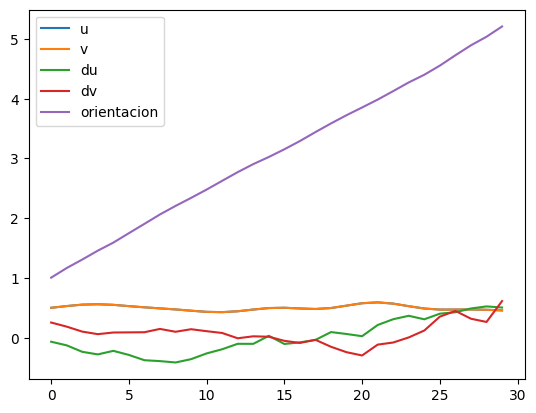

fa_trans min/max: 1.1965537426627988 1.212981199911677
orientacion_trans_smooth min/max: 1.0060112805417274 5.20789164428508
u_trans_smooth min/max: 0.428894336949768 0.592519373555156
v_trans_smooth min/max: 0.428894336949768 0.592519373555156


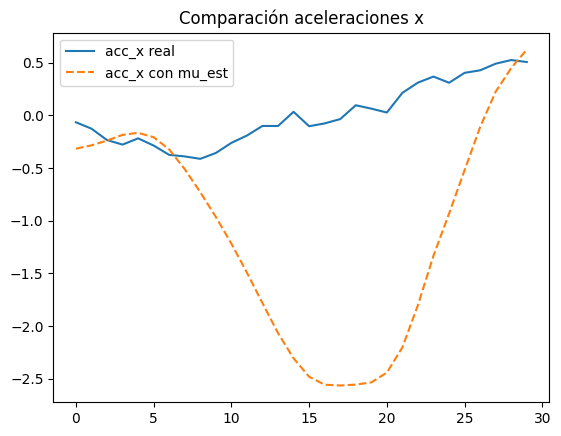

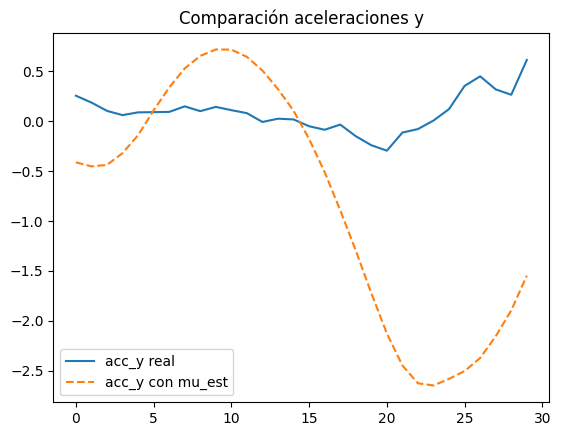

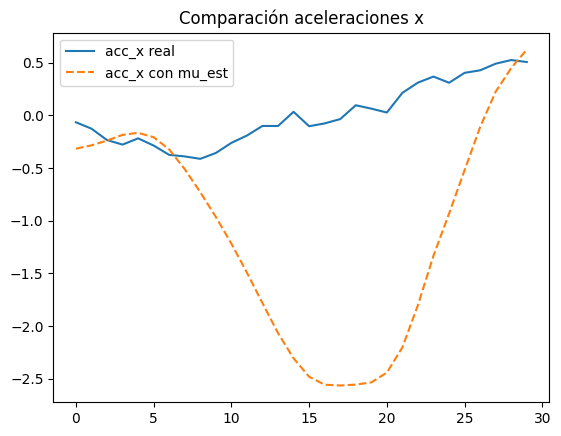

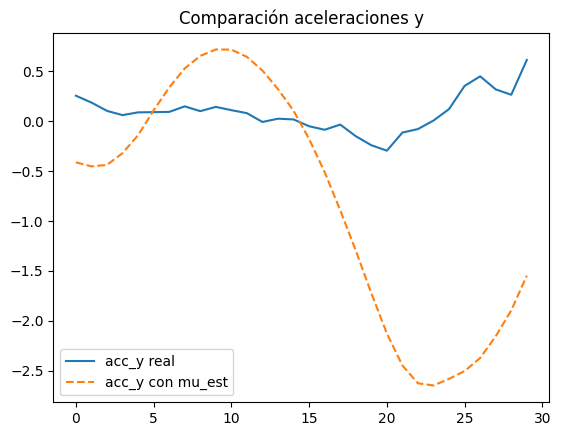

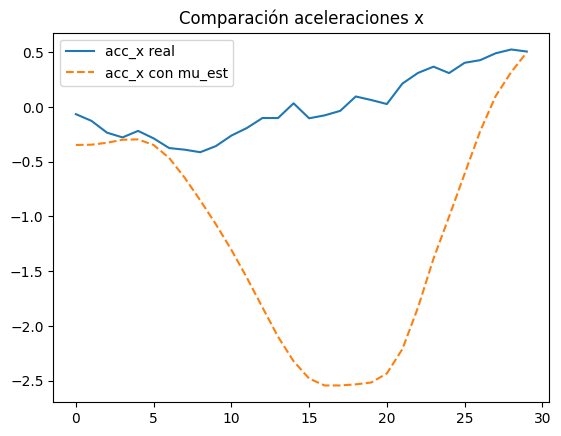

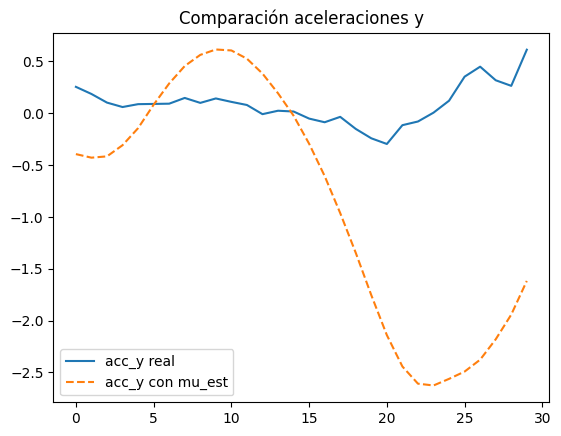

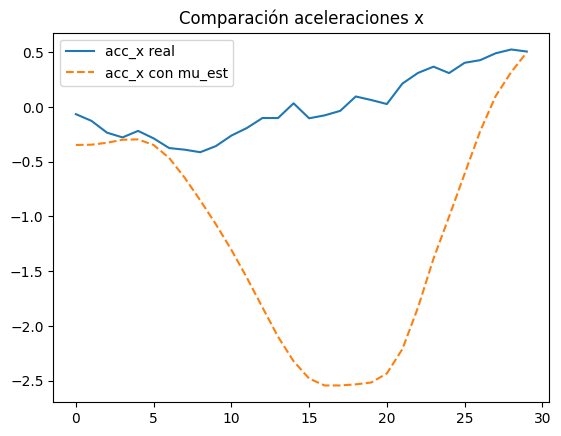

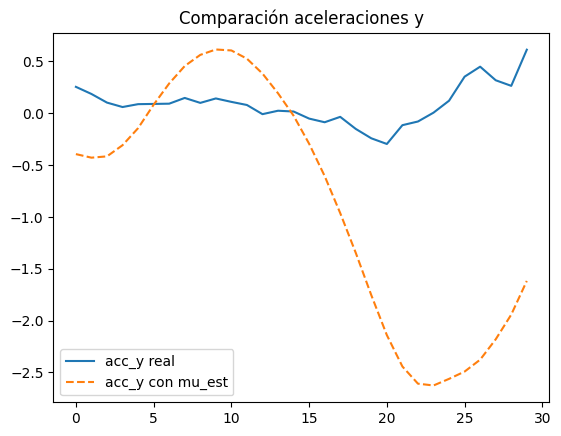

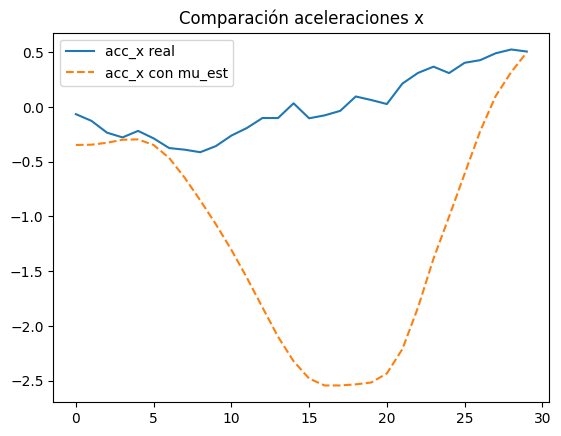

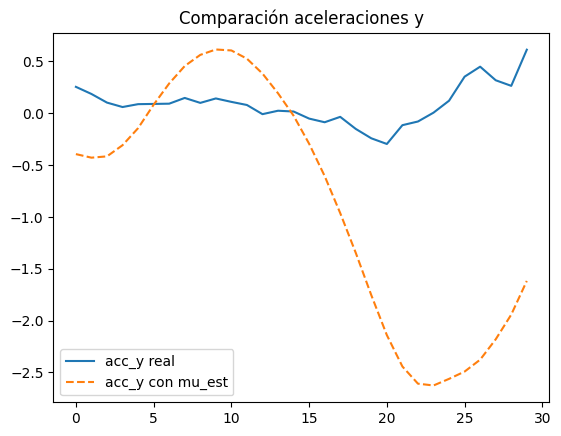

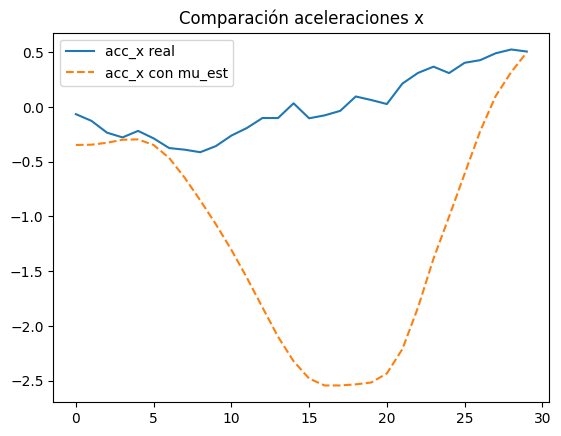

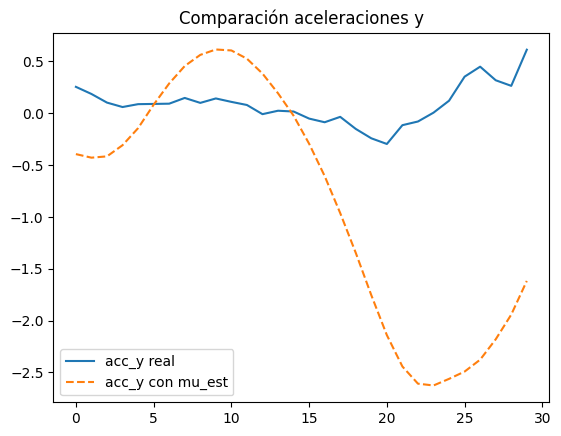

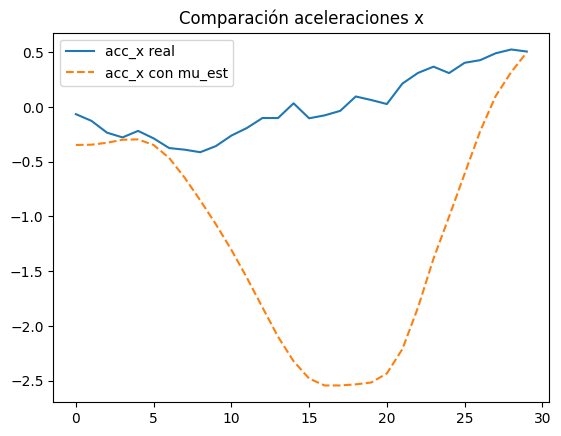

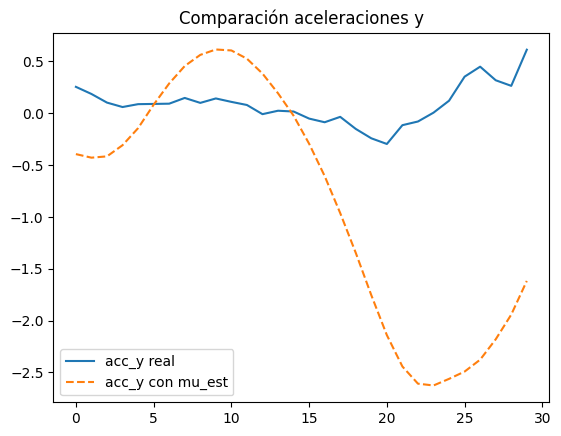


Resultados del modelo de traslación lineal:
Coeficiente de rozamiento en x (mu_x): 2.500000
Coeficiente de rozamiento en y (mu_y): [0.53129144]


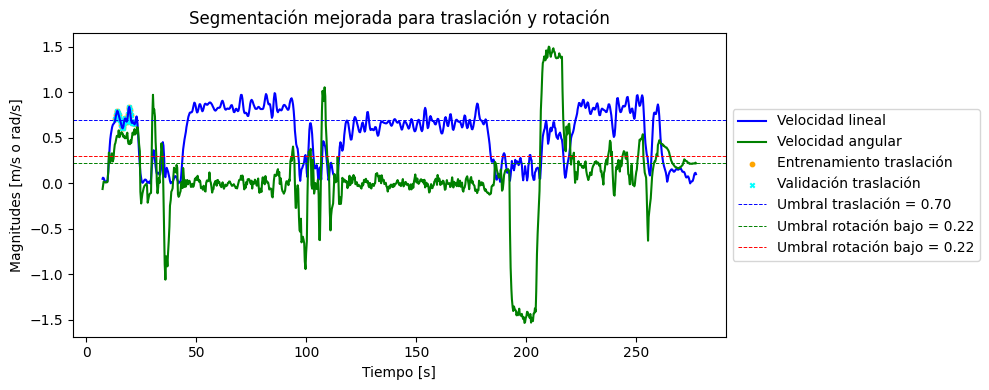


Análisis de traslación completado con éxito.
Los resultados se han guardado en los archivos 'ajuste_traslacion.png' y 'simulacion_traslacion.png'


In [11]:
### MAIN #############################################
if __name__ == "__main__":
    # try:
    print("Iniciando análisis de rozamiento de traslación...")
    resultados = analizar_traslacion(rozamiento = "x")
    print("\nAnálisis de traslación completado con éxito.")
    print("Los resultados se han guardado en los archivos 'ajuste_traslacion.png' y 'simulacion_traslacion.png'")
    # except Exception as e:
    #     print(f"Error durante el análisis: {e}")
    #     print("Nota: Es posible que necesite ajustar la ruta de los archivos de datos en la función extraccion_datos().")
